Steps I took to improve:
fixed class imbalance by stratify
added class weight because want to make sure model is not predicting the majority class. accurancy went down when class weight was added
removed drop_first to be able to see all feature importance but might have multicollinearily. so hoping regularization fixes that

In [190]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, log_loss, accuracy_score, balanced_accuracy_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
 

In [191]:
df = pd.read_csv('cleaned_data.csv')
df.head()

,Unnamed: 0,ForceType,Sex,Race,TypeOfResistance,Neighborhood,Problem,PrimaryOffense
0,0,Bodily Force,Female,Black,Tensed,Folwell,Fight,DISCON
1,1,Bodily Force,Male,Black,Fled in Vehicle,Wenonah,Suspicious Vehicle,FLEE
2,2,Bodily Force,Male,Black,Verbal Non-Compliance,Ventura Village,Trespass in Boarded Dwell,NARC
3,3,Taser,Male,White,Tensed,Minnehaha,Emotionally Disturb Person,FENTRY
4,4,Bodily Force,Male,White,Verbal Non-Compliance,Harrison,Person with a Gun,OBSTRU


In [192]:
#grouped the smaller Race types together to reduce class imbalance
df['Race'] = df['Race'].replace('Other / Mixed Race', 'other')
df['Race'] = df['Race'].replace('Pacific Islander', 'other')
df['Race'] = df['Race'].replace('Asian', 'other')
df['Race'] = df['Race'].replace('Unknown', 'other')
df = df[df['Race'] != 'not recorded']
print(df['Race'].value_counts())

Race
Black              18397
White               7217
other               2148
Native American     1571
Name: count, dtype: int64


In [193]:
#removed not recorded Sex as this is similar to NULL data but kept unknown as this at least means a Sex type was collected by the Police officer
df = df[df['Sex'] != 'not recorded']
print(df['Sex'].value_counts())

Sex
Male       25340
Female      3800
Unknown      189
Name: count, dtype: int64


In [194]:
#Combining ForceType categories to help reduce class imbalance
force_map = {
    "Bodily Force": "Bodily force",
    "Maximal Restraint Technique": "Bodily force",

    "Chemical Irritant": "Chemical Irritant",

    "Less Lethal Projectile": "Less-lethal weapons",
    "Baton": "Less-lethal weapons",
    "Less Lethal": "Less-lethal weapons",
    "Taser": "Less-lethal weapons",
    "Improvised Weapon": "Less-lethal weapons",
    "Police K9 Bite": "Less-lethal weapons",

    "Gun Point Display": "Guns",
    "Firearm": "Guns"
}


df["ForceType"] = df["ForceType"].map(force_map)
print(df["ForceType"].value_counts())


ForceType
Bodily force           21364
Chemical Irritant       3971
Less-lethal weapons     3528
Guns                     466
Name: count, dtype: int64


In [195]:
#first cleaned up the phrasing of my types of resistance
#lower makes sure all of the same types of resistance can be grouped together irrespective of capitalization and strip removed leading or trailing spaces as these values 
#are manually inputted and might have some human error
df['TypeOfResistance'] = df['TypeOfResistance'].str.strip().str.lower()

# mapping phrasing together 
df['TypeOfResistance'] = df['TypeOfResistance'].replace({
    'commission of a crime': 'commission of crime',
    'fled in a vehicle': 'fled in vehicle',
    'assaulted police horse': 'assaulting police horse',
    'assaulted police k9': 'assaulting police k9'
})
print(df['TypeOfResistance'].value_counts())

TypeOfResistance
tensed                     8088
commission of crime        6146
fled on foot               4542
assaulted officer          3260
verbal non-compliance      3218
unspecified                2082
other                      1056
fled in vehicle             838
assaulting police horse      51
x                            33
assaulting police k9         15
Name: count, dtype: int64


In [196]:
#then grouped various types of resistance together. 
df["TypeOfResistance"] = df["TypeOfResistance"].str.strip().str.lower()
df = df[df["TypeOfResistance"] != 'x']

resistance_map = {
    "assaulted officer": "Assaulting",
    "assaulting police horse": "Assaulting",
    "assaulting police k9": "Assaulting",
    "assaulted police k9": "Assaulting",

    "fled on foot": "Fleeing",
    "fled in a vehicle": "Fleeing",
    "fled in vehicle": "Fleeing",

    "commission of crime": "Commission of Crime",
    "commission of a crime": "Commission of Crime",

    "unspecified": "Other/Unspecified",
    "other": "Other/Unspecified",

    "tensed": "Tensed",
    
    "verbal non-compliance": "Verbal Non-Compliance"
}

df["TypeOfResistance"] = df["TypeOfResistance"].replace(resistance_map)
print(df['TypeOfResistance'].value_counts())

TypeOfResistance
Tensed                   8088
Commission of Crime      6146
Fleeing                  5380
Assaulting               3326
Verbal Non-Compliance    3218
Other/Unspecified        3138
Name: count, dtype: int64


In [197]:
#grouped problem types together as there are over 200 unique problem types and created unnecessary class imbalance. I created a new column for Problem type to be able to validate
#the mappings 
problem_map = {
    "fight": "Violent", "assault in progress": "Violent", "assault report only": "Violent",
    "stabbing": "Violent", "shooting": "Violent", "shooting report only": "Violent",
    "robbery of person": "Violent", "robbery dwell in progress": "Violent",
    "robbery of biz in progress": "Violent", "robbery dwlng/person rpt": "Violent",
    "robbery of biz - report": "Violent", "person with a gun": "Violent",
    "person with a weapon": "Violent", "domestic with weapons": "Violent",
    "shotspotter activation": "Violent", "sound of shots fired": "Violent",
    "holdup alarm": "Violent", "kidnapping/abduction": "Violent",

    "domestic abuse-in progress": "Domestic", "domestic abuse report only": "Domestic",
    "domestic": "Domestic", "neighbor trouble": "Domestic", "tenant trouble": "Domestic",
    "retrieve prop/dom situation": "Domestic", "threats": "Domestic",
    "crim sex conduct": "Domestic", "crim sex conduct/report": "Domestic",

    "suspicious person": "Suspicious & Disorder", "suspicious vehicle": "Suspicious & Disorder",
    "disturbance": "Suspicious & Disorder", "unwanted person": "Suspicious & Disorder",
    "customer trouble": "Suspicious & Disorder", "loud party": "Suspicious & Disorder",
    "music-loud": "Suspicious & Disorder", "drunk/intoxicated person": "Suspicious & Disorder",
    "narcotics": "Suspicious & Disorder", "indecent exposure": "Suspicious & Disorder",
    "prowler": "Suspicious & Disorder", "trespass in boarded dwell": "Suspicious & Disorder",
    "unknown trouble": "Suspicious & Disorder", "curfew violations": "Suspicious & Disorder",
    "hotrodders": "Suspicious & Disorder", "suspected prostitute": "Suspicious & Disorder",
    "attempt pick-up": "Suspicious & Disorder", "walk through a building": "Suspicious & Disorder",
    "parking problem": "Suspicious & Disorder", "truancy": "Suspicious & Disorder",
    "firecrackers": "Suspicious & Disorder", "kid trouble": "Suspicious & Disorder",

    "burglary dwlng in progress": "Property & Vehicle", "burglary biz - in progress": "Property & Vehicle",
    "burglary dwlng - report": "Property & Vehicle", "burglary business - report": "Property & Vehicle",
    "theft": "Property & Vehicle", "theft-hold one cooperative": "Property & Vehicle",
    "theft - report only": "Property & Vehicle", "auto theft in progress": "Property & Vehicle",
    "auto theft": "Property & Vehicle", "bait vehicle auto theft": "Property & Vehicle",
    "recover vehicle": "Property & Vehicle", "recover property": "Property & Vehicle",
    "motor vehicle chase": "Property & Vehicle", "chase on foot": "Property & Vehicle",
    "forgery in progress": "Property & Vehicle", "forgery report": "Property & Vehicle",
    "damage property-in progress": "Property & Vehicle", "damage property-rpt only": "Property & Vehicle",
    "traffic law enforcement": "Property & Vehicle", "property damage accident": "Property & Vehicle",
    "personal injury accident": "Property & Vehicle", "property damage/hit & run": "Property & Vehicle",
    "poss personal injury acc": "Property & Vehicle", "personal inj/hit and run": "Property & Vehicle",
    "audible business alarm": "Property & Vehicle", "audible residential alarm": "Property & Vehicle",
    "audible alarm": "Property & Vehicle", "silent alarm": "Property & Vehicle",
    "panic alarm": "Property & Vehicle",

    "emotionally disturb person": "Welfare & Emergency", "check the welfare": "Welfare & Emergency",
    "attempted suicide": "Welfare & Emergency", "person threat to jump": "Welfare & Emergency",
    "down outside-one": "Welfare & Emergency", "down outside-one w/fire": "Welfare & Emergency",
    "down outide-one w/fire": "Welfare & Emergency", "slumper": "Welfare & Emergency",
    "slumper w/fire": "Welfare & Emergency", "unconscious": "Welfare & Emergency",
    "overdose-accidental": "Welfare & Emergency", "overdose w/all": "Welfare & Emergency",
    "overdose w/alll": "Welfare & Emergency", "officer needs help": "Welfare & Emergency",
    "assist an officer": "Welfare & Emergency", "assist other agency": "Welfare & Emergency",
    "assist ems personnel": "Welfare & Emergency", "assist fire personnel": "Welfare & Emergency",
    "paramedic needs help": "Welfare & Emergency", "high risk warrant entry": "Welfare & Emergency",
    "code 3": "Welfare & Emergency", "dead person": "Welfare & Emergency",
    "missing person": "Welfare & Emergency", "lost child": "Welfare & Emergency",
    "drowning": "Welfare & Emergency", "miscellaneous": "Welfare & Emergency",
    "unknown wireless/cell phone": "Welfare & Emergency", "on site": "Welfare & Emergency",
    "transportation": "Welfare & Emergency", "directed patrol": "Welfare & Emergency",
    "assist a disabled person": "Welfare & Emergency", "pandemic emergency": "Welfare & Emergency",
    "police event": "Welfare & Emergency", "receive information": "Welfare & Emergency",
    "business check": "Welfare & Emergency", "community engagement meeting": "Welfare & Emergency",
    "suspected hazard": "Welfare & Emergency", "check hazard": "Welfare & Emergency",
    "foot beat": "Welfare & Emergency", "firefighter needs help": "Welfare & Emergency",
    "assist-public": "Welfare & Emergency", "road hazard": "Welfare & Emergency",
    "wires down": "Welfare & Emergency", "animal bite": "Welfare & Emergency",
    "animal call": "Welfare & Emergency", "aggressive dog": "Welfare & Emergency",
    "fire-report only": "Welfare & Emergency", "pi w/trapped": "Welfare & Emergency",
    "elevator emergency": "Welfare & Emergency", "diabetic problem": "Welfare & Emergency",
    "baby not breathing": "Welfare & Emergency", "test/demo ee & cad oper": "Welfare & Emergency",
    "crank 9-1-1 call": "Welfare & Emergency", "aircraft crash in city": "Welfare & Emergency",
}

df['Problem_Group'] = df['Problem'].str.strip().str.lower().map(problem_map).fillna("Welfare & Emergency")
print(df['Problem_Group'].value_counts())

Problem_Group
Suspicious & Disorder    11630
Violent                   6243
Property & Vehicle        4339
Welfare & Emergency       4218
Domestic                  2866
Name: count, dtype: int64


In [198]:
target_col = "ForceType"
feature_cols = ["Race", "Sex", "TypeOfResistance","Problem_Group"]

#decided to drop_first = True to make the feature importance and weights interpretation easier
df_X = pd.get_dummies(df[feature_cols], drop_first=True, dtype=int).copy()

df_X.head()



,Race_Native American,Race_White,Race_other,Sex_Male,Sex_Unknown,TypeOfResistance_Commission of Crime,TypeOfResistance_Fleeing,TypeOfResistance_Other/Unspecified,TypeOfResistance_Tensed,TypeOfResistance_Verbal Non-Compliance,Problem_Group_Property & Vehicle,Problem_Group_Suspicious & Disorder,Problem_Group_Violent,Problem_Group_Welfare & Emergency
0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
1,0,0,0,1,0,0,1,0,0,0,0,1,0,0
2,0,0,0,1,0,0,0,0,0,1,0,1,0,0
3,0,1,0,1,0,0,0,0,1,0,0,0,0,1
4,0,1,0,1,0,0,0,0,0,1,0,0,1,0


In [199]:
#label encoded the target variable instead of one hot encoding to only have 1 y column instead of 4
le = LabelEncoder() 
df_y = le.fit_transform(df[target_col])
df_y   

array([0, 0, 0, ..., 3, 0, 0], shape=(29296,))

In [200]:
#printed this to understand which indices were encoded for each force type 
for i,forcetype in set(zip(df['ForceType'],df_y)):
    print(forcetype, i)

1 Chemical Irritant
3 Less-lethal weapons
0 Bodily force
2 Guns


In [201]:
#good way to visualize the class imbalance for the target variable
print(df['ForceType'].value_counts())

ForceType
Bodily force           21343
Chemical Irritant       3970
Less-lethal weapons     3517
Guns                     466
Name: count, dtype: int64


In [202]:
df_X.head()
#type of resistance

,Race_Native American,Race_White,Race_other,Sex_Male,Sex_Unknown,TypeOfResistance_Commission of Crime,TypeOfResistance_Fleeing,TypeOfResistance_Other/Unspecified,TypeOfResistance_Tensed,TypeOfResistance_Verbal Non-Compliance,Problem_Group_Property & Vehicle,Problem_Group_Suspicious & Disorder,Problem_Group_Violent,Problem_Group_Welfare & Emergency
0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
1,0,0,0,1,0,0,1,0,0,0,0,1,0,0
2,0,0,0,1,0,0,0,0,0,1,0,1,0,0
3,0,1,0,1,0,0,0,0,1,0,0,0,0,1
4,0,1,0,1,0,0,0,0,0,1,0,0,1,0


In [203]:
#only did 1 fold CV because I am already going to be iterating over different hyperparameters and didnt want to make the code take too much longer to run (might change)
#stratify = target variable to make sure the class imbalance is being accounted for in the train and test sets. 
X_train, X_test, y_train, y_test = train_test_split(
 df_X, df_y, test_size=0.20, random_state=6243, stratify=df_y #for class imbalance
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((23436, 14), (5860, 14), (23436,), (5860,))

In [204]:
#tested out logisitic regression with 1 set of hyperparameters and I got some results! 
log_reg_1 = LogisticRegression(solver="lbfgs", max_iter=10000, class_weight = 'balanced') 

log_reg_1.fit(X_train, y_train)

log_reg_1.intercept_, log_reg_1.coef_

(array([ 1.26907479, -0.18613808, -1.73838725,  0.65545055]),
 array([[ 0.1365193 ,  0.15717677, -0.09275971, -0.50640741, -0.78549359,
         -0.82696112, -0.27106245, -0.469707  ,  0.04738348, -0.85017801,
         -0.15605124, -0.26099497, -0.60996011, -0.31723337],
        [-0.63627908, -0.14348738,  0.16502616, -1.31457343,  0.42889737,
          1.10956303, -0.46657465,  0.73916509,  0.22165338,  1.06096627,
          0.07995513,  0.96953148,  0.99199888,  0.55890735],
        [ 0.22007876, -0.20645546,  0.00276442,  1.81414593, -0.54720516,
          0.21750772,  0.56692797,  0.15340972,  0.08533522,  0.2545815 ,
          0.17444863, -0.35987381,  0.15953319, -0.10051728],
        [ 0.27968102,  0.19276607, -0.07503087,  0.00683491,  0.90380138,
         -0.50010962,  0.17070913, -0.42286781, -0.35437208, -0.46536976,
         -0.09835252, -0.3486627 , -0.54157196, -0.1411567 ]]))

In [ ]:
#decided to iterate over different C, solvers and l1ratio options to find the best model
# max_iter = 10000 to make sure the solver converges to a value instead of running infinitely
# tol=0.01 because I was getting solver couldn't converge errors so I added this stopping criteria
# random_state = 0 because I kept getting different highest accurancy scores and I needed to make a concrete decision on the best hyperparameters to pick
# class_weight= balance because we have a class imbalance issue and I needed to account for in the CV split and also the model building
# 
C_options = [0.1, 1, 10, 100]
solver_options = ['lbfgs', 'saga']
l1ratio_options = [0.0, 0.25, 0.5, 0.75, 1]


for C in C_options:
    for solver in solver_options:
        for l1_ratio in l1ratio_options:
            try:
                log_reg = LogisticRegression(solver=solver, C = C, l1_ratio = l1_ratio, max_iter=10000, class_weight = 'balanced', tol=0.01, random_state=0) #make sure I want to use that solver
                log_reg.fit(X_train, y_train)
                yhat_log = log_reg.predict(X_test)
                balanced_accuracy = balanced_accuracy_score (y_test, yhat_log)
                print(f"C={C}, solver={solver}, l1ratio={l1_ratio}, balanced_accuracy={balanced_accuracy:.4f}")
                
            except:
                continue


C=0.1, solver=lbfgs, l1ratio=0.0, accuracy=0.4230


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C=0.1, solver=saga, l1ratio=0.0, accuracy=0.3729


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C=0.1, solver=saga, l1ratio=0.25, accuracy=0.3824


...

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C=100, solver=saga, l1ratio=0.5, accuracy=0.3266


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C=100, solver=saga, l1ratio=0.75, accuracy=0.3829
C=100, solver=saga, l1ratio=1, accuracy=0.3332


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C=0.1, solver=lbfgs, l1ratio=0.0,accuracy=0.4230


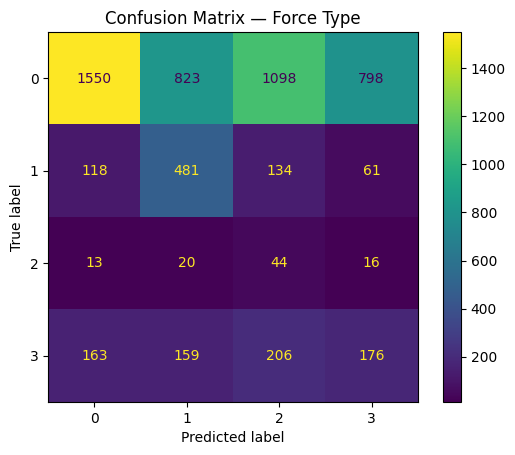

In [ ]:
#best model
#C=0.1, solver=lbfgs, l1ratio=0.0, accuracy=0.4230
#3 models had a tied balanced accurancy of 0.4230
#I picked balanced accuracy because the dataset has class imbalance and balanced accuracy gives equal weight to each class. 
#the models with solver = lbgfs and l1ratio = 0 all have the same and highest balanced accuracy score irrespective of the C penalty. 


log_reg_best = LogisticRegression(solver='lbfgs', C = 0.1, l1_ratio = 0.0, max_iter=10000, class_weight = 'balanced', tol=0.01, random_state=0) #make sure I want to use that solver
log_reg_best.fit(X_train, y_train)
yhat_log_best = log_reg_best.predict(X_test)
balanced_accuracy_balanced = balanced_accuracy_score(y_test, yhat_log_best)
print(f"C={log_reg_best.C}, solver={log_reg_best.solver}, l1ratio={log_reg_best.l1_ratio},accuracy={balanced_accuracy_balanced:.4f}")

ConfusionMatrixDisplay.from_predictions(y_test, yhat_log_best)
plt.title("Confusion Matrix — Force Type")
plt.show()

In [206]:
list(df_X.columns)

['Race_Native American',
 'Race_White',
 'Race_other',
 'Sex_Male',
 'Sex_Unknown',
 'TypeOfResistance_Commission of Crime',
 'TypeOfResistance_Fleeing',
 'TypeOfResistance_Other/Unspecified',
 'TypeOfResistance_Tensed',
 'TypeOfResistance_Verbal Non-Compliance',
 'Problem_Group_Property & Vehicle',
 'Problem_Group_Suspicious & Disorder',
 'Problem_Group_Violent',
 'Problem_Group_Welfare & Emergency']

In [ ]:
#in addition to feature importance, I also wanted to see how the weights of each input impact each class of target variables. 
coef_df_logreg = pd.DataFrame({
    "feature": ['intercept'] + list(df_X.columns),
    "BodilyForce_w": [log_reg_best.intercept_[0]] + list(log_reg_best.coef_[0]),
    "ChemicalIrritant_w": [log_reg_best.intercept_[1]] + list(log_reg_best.coef_[1]),
    "Guns_w": [log_reg_best.intercept_[2]] + list(log_reg_best.coef_[2]),
    "LessLethalWeapons_w": [log_reg_best.intercept_[3]] + list(log_reg_best.coef_[3])


    #"weights": log_reg.coef_.T
    
})
coef_df_logreg

,feature,BodilyForce_w,ChemicalIrritant_w,Guns_w,LessLethalWeapons_w
0,intercept,0.063644,0.175387,-0.225765,-0.013266
1,Race_Native American,0.036793,-0.144601,0.040987,0.066821
2,Race_White,0.209655,-0.142116,-0.247890,0.180350
3,Race_other,-0.086858,0.205860,-0.059996,-0.059006
4,Sex_Male,0.041700,-0.815238,0.537397,0.236141
5,Sex_Unknown,-0.041398,0.091287,-0.062042,0.012153
6,TypeOfResistance_Commission of Crime,-0.473438,0.806422,-0.043730,-0.289254
7,TypeOfResistance_Fleeing,0.026583,-0.737620,0.315024,0.396014
8,TypeOfResistance_Other/Unspecified,-0.028188,0.191019,-0.080900,-0.081930
9,TypeOfResistance_Tensed,0.562931,-0.338859,-0.164942,-0.059129


In [252]:
print(df['Sex'].unique())
print(pd.get_dummies(df['Sex'], drop_first=True, dtype=int).columns.to_list())

print(df['Race'].unique())
print(pd.get_dummies(df['Race'], drop_first=True, dtype=int).columns.to_list())

print(df['TypeOfResistance'].unique())
print(pd.get_dummies(df['TypeOfResistance'], drop_first=True, dtype=int).columns.to_list())

print(df['Problem_Group'].unique())
print(pd.get_dummies(df['Problem_Group'], drop_first=True, dtype=int).columns.to_list())


['Female' 'Male' 'Unknown']
['Male', 'Unknown']
['Black' 'White' 'other' 'Native American']
['Native American', 'White', 'other']
['Tensed' 'Fleeing' 'Verbal Non-Compliance' 'Other/Unspecified'
 'Commission of Crime' 'Assaulting']
['Commission of Crime', 'Fleeing', 'Other/Unspecified', 'Tensed', 'Verbal Non-Compliance']
['Violent' 'Suspicious & Disorder' 'Welfare & Emergency'
 'Property & Vehicle' 'Domestic']
['Property & Vehicle', 'Suspicious & Disorder', 'Violent', 'Welfare & Emergency']


In [99]:
# Dropped Values
# Sex = Female
# Race = Black
# Type of Resistance = Assaulting
# Problem Group = Domestic

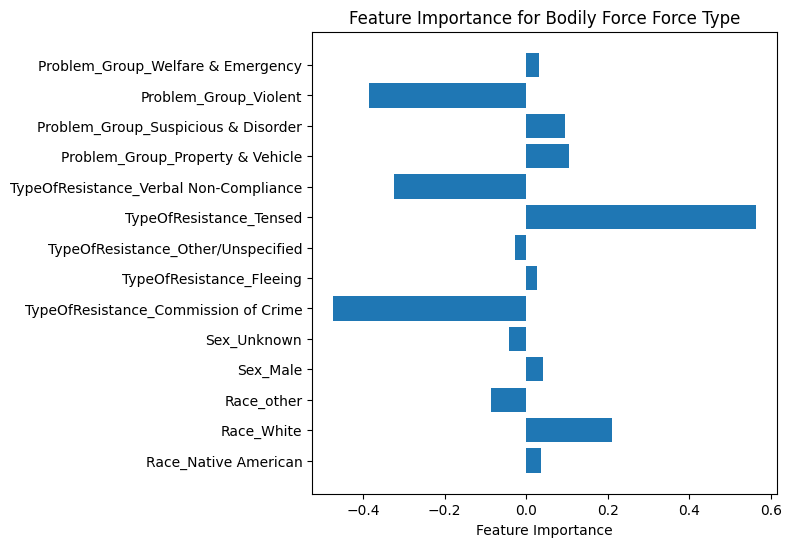

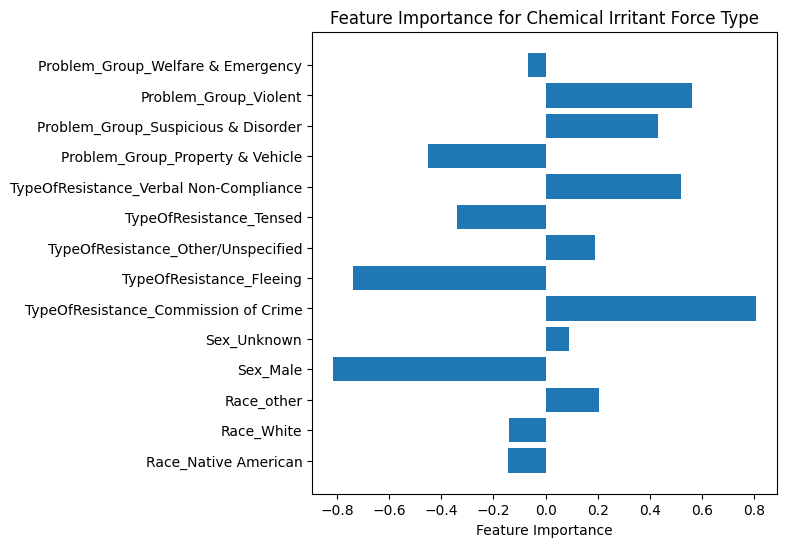

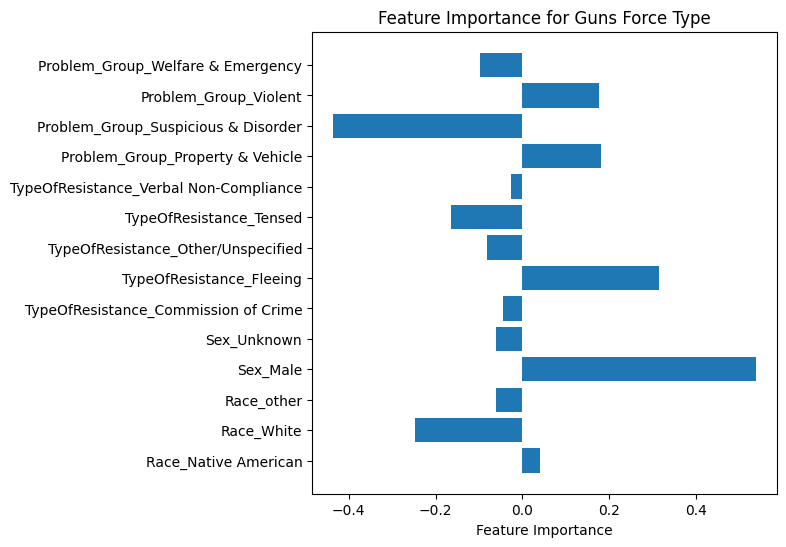

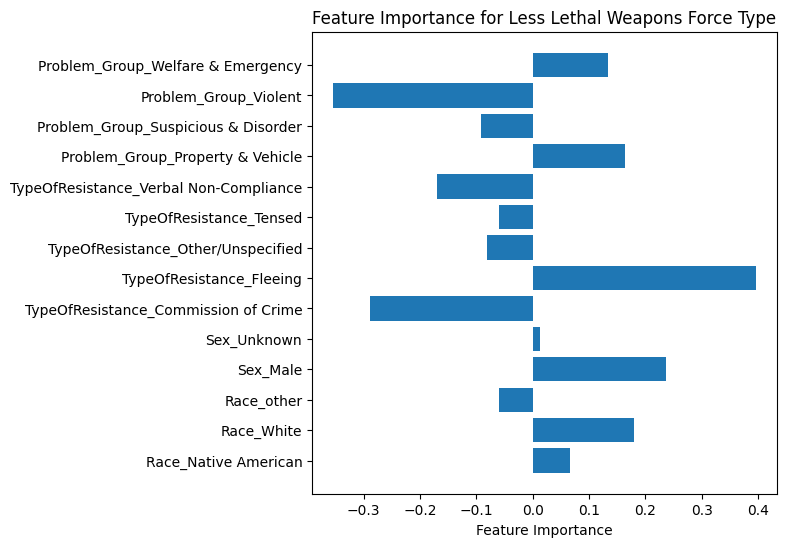

In [ ]:
df_plot = coef_df_logreg.set_index('feature')

plt.figure(figsize=(6,6))
plt.barh(df_plot.iloc[1:,0].index, df_plot.iloc[1:,0].values)
plt.xlabel("Feature Importance")
plt.title("Feature Importance for Bodily Force Force Type")
plt.show()

plt.figure(figsize=(6,6))
plt.barh(df_plot.iloc[1:,1].index, df_plot.iloc[1:,1].values)
plt.xlabel("Feature Importance")
plt.title("Feature Importance for Chemical Irritant Force Type")
plt.show()

plt.figure(figsize=(6,6))
plt.barh(df_plot.iloc[1:,2].index, df_plot.iloc[1:,2].values)
plt.xlabel("Feature Importance")
plt.title("Feature Importance for Guns Force Type")
plt.show()

plt.figure(figsize=(6,6))
plt.barh(df_plot.iloc[1:,3].index, df_plot.iloc[1:,3].values)
plt.xlabel("Feature Importance")
plt.title("Feature Importance for Less Lethal Weapons Force Type")
plt.show()

# Dropped Values
# Sex = Female
# Race = Black
# Type of Resistance = Assaulting
# Problem Group = Domestic


# a police officer is more likely to use bodily force on a white race than a black race.
# a police officer is more likely to use bodily force on a tensed type of resistance (which means a person is phyiscal tense or uncooperative) than assaulting type of resistance.
# a police offer is less likely to use bodily force on someone who is resisting through commission of crime than assaulting.
# a police officer is less likely to use bodily force on a problem related to violence than a domestic problem 
# a police officer is less likely to use chemical irritant on a male than a female. 
# a police officer is more likely to use a gun on a male than a female.


Gradient Descent by hand

In [254]:
df_X

,Race_Native American,Race_White,Race_other,Sex_Male,Sex_Unknown,TypeOfResistance_Commission of Crime,TypeOfResistance_Fleeing,TypeOfResistance_Other/Unspecified,TypeOfResistance_Tensed,TypeOfResistance_Verbal Non-Compliance,Problem_Group_Property & Vehicle,Problem_Group_Suspicious & Disorder,Problem_Group_Violent,Problem_Group_Welfare & Emergency
0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
1,0,0,0,1,0,0,1,0,0,0,0,1,0,0
2,0,0,0,1,0,0,0,0,0,1,0,1,0,0
3,0,1,0,1,0,0,0,0,1,0,0,0,0,1
4,0,1,0,1,0,0,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29707,1,0,0,1,0,0,0,0,0,1,0,0,0,0
29708,0,1,0,1,0,0,0,0,1,0,0,0,0,1
29709,0,0,0,1,0,0,0,1,0,0,0,0,0,0
29711,0,0,1,0,0,0,0,0,1,0,0,0,0,1


In [ ]:
#created my feature matrix and the target vector
n = df_X.shape[0]
X = df_X.to_numpy()
Phi = np.hstack([np.ones(n).reshape(-1,1), X])  
print(Phi)
y_vec = df_y.reshape(-1, 4) 
print(Phi.shape)
print(y_vec)


[[1. 0. 0. ... 0. 1. 0.]
 [1. 0. 0. ... 1. 0. 0.]
 [1. 0. 0. ... 1. 0. 0.]
 ...
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 1.]
 [1. 0. 0. ... 0. 0. 1.]]
(29296, 15)
[[0 0 0 3]
 [0 0 0 0]
 [0 0 0 0]
 ...
 [3 0 0 0]
 [0 0 0 3]
 [0 3 0 0]]


In [ ]:

n = df_X.shape[0]
X = df_X.to_numpy()
Phi = np.hstack([np.ones((n,1)), X]) 
d = Phi.shape[1]

def mse(w, Phi, y):
	resid = Phi @ w - y
	return ((1/n)*np.sum(resid**2)).item()

def grad(w, Phi, y):
	dfdw = Phi.T@(Phi @ w  - y)
	return dfdw
	


In [ ]:
rng = np.random.default_rng(6243)
w = rng.standard_normal((d, 4))
eta = 0.00001 #needed to pick a small learning rate because I kept getting errors.
epochs = 1000
y_vec_dummies = pd.get_dummies(pd.Series(df_y.flatten()), dtype=float).to_numpy()

mse_hist = []

for t in range(epochs):
    w = w - eta*grad(w, Phi, y_vec_dummies)
    mse_hist.append(mse(w, Phi, y_vec_dummies))



w_df = pd.DataFrame({
    "feature": ['intercept'] + list(df_X.columns),
    "BodilyForce_w": list(w[:,0]),
    "ChemicalIrritant_w": list(w[:,1]),
    "Guns_w": list(w[:,2]),
    "LessLethalWeapons_w": list(w[:,3])

    
})
w_df

,feature,BodilyForce_w,ChemicalIrritant_w,Guns_w,LessLethalWeapons_w
0,intercept,0.837898,0.099197,-0.003378,0.070470
1,Race_Native American,0.027843,-0.061762,0.002221,0.031410
2,Race_White,0.028160,-0.032299,-0.005704,0.009941
3,Race_other,-0.031479,0.053377,0.002404,-0.011435
4,Sex_Male,0.062789,-0.146432,0.015024,0.061586
5,Sex_Unknown,-0.273981,-0.008623,-0.035557,0.163854
6,TypeOfResistance_Commission of Crime,-0.229796,0.217031,0.008919,0.003948
7,TypeOfResistance_Fleeing,-0.064223,0.006505,0.007124,0.050555
8,TypeOfResistance_Other/Unspecified,-0.105024,0.108980,0.001771,-0.005157
9,TypeOfResistance_Tensed,0.022020,0.017438,-0.001097,-0.038791


Going to try downsampling to see how that impacts the accuracy scores and overall prediction

In [ ]:
#copied the dataframe so I don't have to re-map everything
cleaned_df = df.copy()
cleaned_df = cleaned_df.drop(columns = ['Unnamed: 0', 'Neighborhood','PrimaryOffense', 'Problem'])
cleaned_df


,ForceType,Sex,Race,TypeOfResistance,Problem_Group
0,Bodily force,Female,Black,Tensed,Violent
1,Bodily force,Male,Black,Fleeing,Suspicious & Disorder
2,Bodily force,Male,Black,Verbal Non-Compliance,Suspicious & Disorder
3,Less-lethal weapons,Male,White,Tensed,Welfare & Emergency
4,Bodily force,Male,White,Verbal Non-Compliance,Violent
...,...,...,...,...,...
29707,Less-lethal weapons,Male,Native American,Verbal Non-Compliance,Domestic
29708,Bodily force,Male,White,Tensed,Welfare & Emergency
29709,Less-lethal weapons,Male,Black,Other/Unspecified,Domestic
29711,Bodily force,Female,other,Tensed,Welfare & Emergency


In [ ]:
#found the smallest class in the target variable and will resample based on that
min_group = cleaned_df['ForceType'].value_counts().min()
min_group

np.int64(466)

In [260]:
resampled = []
for clas in cleaned_df['ForceType'].unique():
    resampled.append(resample(cleaned_df[cleaned_df['ForceType']== clas],replace = False, n_samples = min_group, random_state = 0))
df_balanced = pd.concat(resampled)
df_balanced

,ForceType,Sex,Race,TypeOfResistance,Problem_Group
16595,Bodily force,Female,White,Tensed,Violent
11891,Bodily force,Male,White,Commission of Crime,Property & Vehicle
6656,Bodily force,Male,White,Commission of Crime,Property & Vehicle
6431,Bodily force,Male,Black,Fleeing,Suspicious & Disorder
7260,Bodily force,Male,Black,Tensed,Suspicious & Disorder
...,...,...,...,...,...
17744,Guns,Male,Black,Verbal Non-Compliance,Property & Vehicle
13183,Guns,Male,Black,Commission of Crime,Violent
11057,Guns,Male,Native American,Verbal Non-Compliance,Welfare & Emergency
8565,Guns,Male,Black,Tensed,Suspicious & Disorder


In [261]:
print(df_balanced['ForceType'].value_counts())

ForceType
Bodily force           466
Less-lethal weapons    466
Chemical Irritant      466
Guns                   466
Name: count, dtype: int64


In [262]:
target_col = "ForceType"
feature_cols = ["Race", "Sex", "TypeOfResistance","Problem_Group"]

#decided to drop_first = True to make the feature importance and weights interpretation easier
df_X_balanced = pd.get_dummies(df_balanced[feature_cols], drop_first=True, dtype=int).copy()

df_X_balanced.head()

,Race_Native American,Race_White,Race_other,Sex_Male,Sex_Unknown,TypeOfResistance_Commission of Crime,TypeOfResistance_Fleeing,TypeOfResistance_Other/Unspecified,TypeOfResistance_Tensed,TypeOfResistance_Verbal Non-Compliance,Problem_Group_Property & Vehicle,Problem_Group_Suspicious & Disorder,Problem_Group_Violent,Problem_Group_Welfare & Emergency
16595,0,1,0,0,0,0,0,0,1,0,0,0,1,0
11891,0,1,0,1,0,1,0,0,0,0,1,0,0,0
6656,0,1,0,1,0,1,0,0,0,0,1,0,0,0
6431,0,0,0,1,0,0,1,0,0,0,0,1,0,0
7260,0,0,0,1,0,0,0,0,1,0,0,1,0,0


In [263]:
le = LabelEncoder() 
df_y_balanced = le.fit_transform(df_balanced[target_col])
df_y_balanced

array([0, 0, 0, ..., 2, 2, 2], shape=(1864,))

In [266]:
X_train_balanced, X_test_balanced, y_train_balanced, y_test_balanced = train_test_split(
 df_X_balanced, df_y_balanced, test_size=0.20, random_state=0 #, stratify=df_y #for class imbalance
)
X_train_balanced.shape, X_test_balanced.shape, y_train_balanced.shape, y_test_balanced.shape

((1491, 14), (373, 14), (1491,), (373,))

In [269]:
#creating 1 model with the same hyperparameters as the model with the highest balanced accuracy above. 

log_reg_balanced = LogisticRegression(solver='lbfgs', C = 0.1, l1_ratio = 0.0, max_iter=10000, class_weight = 'balanced', tol=0.01, random_state=0)

log_reg_balanced.fit(X_train_balanced, y_train_balanced)

log_reg_balanced.intercept_, log_reg_balanced.coef_

(array([-0.0902676 ,  0.3584565 , -0.33530015,  0.06711125]),
 array([[ 0.13924186,  0.11370757, -0.20510214,  0.22165926, -0.04974962,
         -0.48360114,  0.10550194, -0.035547  ,  0.56095055, -0.52743224,
          0.08969609,  0.03911531, -0.14923997, -0.10475595],
        [-0.20167407, -0.08187377,  0.38605511, -0.97384433,  0.13143027,
          0.55088676, -0.70695754,  0.35665866, -0.32327706,  0.62331951,
         -0.36638119,  0.48793892,  0.35173037,  0.10661173],
        [-0.03342352, -0.3103769 , -0.07924441,  0.70189871, -0.05617201,
         -0.03502516,  0.24247651, -0.20046475, -0.11529255, -0.01707321,
          0.25510662, -0.39438804, -0.00338821, -0.08956683],
        [ 0.09585572,  0.2785431 , -0.10170856,  0.05028636, -0.02550864,
         -0.03226046,  0.35897909, -0.12064691, -0.12238095, -0.07881405,
          0.02157849, -0.13266619, -0.19910219,  0.08771106]]))

C=0.1, solver=lbfgs, l1ratio=0.0,accuracy=0.4187


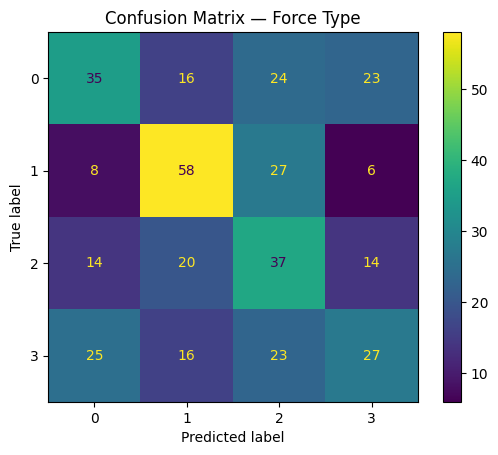

In [ ]:
#does a better job of correctly classifying the labels but still mis-classifying so many bodily force force types as other force types. 
yhat_log_balanced = log_reg_balanced.predict(X_test_balanced)
balanced_accuracy_balanced = balanced_accuracy_score (y_test_balanced, yhat_log_balanced)
print(f"C={log_reg_balanced.C}, solver={log_reg_balanced.solver}, l1ratio={log_reg_balanced.l1_ratio},accuracy={balanced_accuracy_balanced:.4f}")

ConfusionMatrixDisplay.from_predictions(y_test_balanced, yhat_log_balanced)
plt.title("Confusion Matrix — Force Type")
plt.show()